## Phần 1: Khởi tạo môi trường và khám phá dữ liệu

### Bước 1: Khởi tạo SparkSession và nạp dữ liệu đã làm sạch từ HDFS

In [1]:
import os
import sys
import math
import findspark
os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable
findspark.init()

from pyspark.sql import SparkSession, Row
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType, DoubleType
from pyspark.storagelevel import StorageLevel
from IPython.display import display
from pyspark.sql.window import Window
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

spark = SparkSession.builder \
    .appName("Train_Model_Du_Doan_Mua_Hang") \
    .master("spark://26.37.93.102:7077") \
    .config("spark.executor.memory", "10g") \
    .config("spark.driver.memory", "10g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
get_prob1 = F.udf(lambda v: float(v[1]), DoubleType())

print("Đã tạo thành công kết nối SparkSession!")
df = spark.read.parquet("hdfs://master:9000/data/test_cleaned.parquet")
print(f"Tổng số dòng dữ liệu sẵn sàng cho mô hình: {df.count():,}")

Đã tạo thành công kết nối SparkSession!
Tổng số dòng dữ liệu sẵn sàng cho mô hình: 2,711,122


### Bước 2: Khám phá dữ liệu và kiểm tra phân phối nhãn

In [2]:
print("-" * 60)
print("THÔNG TIN SCHEMA")
print("-" * 60)
df.printSchema()

print("\n" + "-" * 60)
print("KIỂM TRA GIÁ TRỊ NULL TRONG TỪNG CỘT")
print("-" * 60)
df.select([F.sum(F.col(c).isNull().cast("int")).alias(c) for c in df.columns]).show(vertical=True)

print("\n" + "-" * 60)
print("PHÂN PHỐI LOẠI SỰ KIỆN (event_type)")
print("-" * 60)
df.groupBy("event_type").count().orderBy(F.desc("count")).show()

print("\n" + "-" * 60)
print("PHÂN PHỐI NHÃN MỤC TIÊU (target)")
print("-" * 60)
df.groupBy("target").count().orderBy("target").show()

print("\n" + "-" * 60)
print("THỐNG KÊ MÔ TẢ CỘT SỐ")
print("-" * 60)
df.select("price", "ts_hour", "ts_weekday").describe().show()

------------------------------------------------------------
THÔNG TIN SCHEMA
------------------------------------------------------------
root
 |-- product_id: string (nullable = true)
 |-- event_time: string (nullable = true)
 |-- event_type: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- user_id: string (nullable = true)
 |-- user_session: string (nullable = true)
 |-- target: long (nullable = true)
 |-- cat_0: string (nullable = true)
 |-- cat_1: string (nullable = true)
 |-- cat_2: string (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- ts_hour: short (nullable = true)
 |-- ts_minute: short (nullable = true)
 |-- ts_weekday: short (nullable = true)
 |-- ts_day: short (nullable = true)
 |-- ts_month: short (nullable = true)
 |-- ts_year: short (nullable = true)


------------------------------------------------------------
KIỂM TRA GIÁ TRỊ NULL TRONG TỪNG CỘT
-------------------------------------------------

---
## Phần 2: Tiền xử lý đặc trưng đầu vào

### Bước 3: Lọc dữ liệu và tạo nhãn

In [3]:
df_valid = (
    df
    .filter(
        (F.col("price") > 0) &
        F.col("timestamp").isNotNull() &
        F.col("product_id").isNotNull() &
        F.col("user_session").isNotNull() &
        F.col("event_type").isin("cart", "purchase")
    )
    .fillna({
        "brand":  "unknown",
        "cat_0":  "unknown",
        "cat_1":  "unknown",
        "cat_2":  "unknown",
    })
    .persist(StorageLevel.MEMORY_AND_DISK)
)

df_cart = (
    df_valid
    .filter(F.col("event_type") == "cart")
    .withColumnRenamed("timestamp", "cart_time")
)

df_purchase = (
    df_valid
    .filter(F.col("event_type") == "purchase")
    .select(
        "user_session",
        "product_id",
        F.col("timestamp").alias("purchase_time")
    )
)

df_session_start = (
    df_valid
    .groupBy("user_session")
    .agg(F.min("timestamp").alias("session_start"))
)

df_labeled = (
    df_cart
    .join(df_purchase, on=["user_session", "product_id"], how="left")
    .groupBy(
        "user_session", "product_id", "cart_time",
        "user_id", "price", "brand",
        "cat_0", "cat_1", "cat_2",
        "ts_hour", "ts_minute", "ts_weekday",
        "ts_day", "ts_month", "ts_year"
    )
    .agg(
        F.min(
            F.when(
                F.col("purchase_time") > F.col("cart_time"),
                F.col("purchase_time")
            )
        ).alias("first_purchase_after_cart")
    )
    .withColumn(
        "label",
        F.when(F.col("first_purchase_after_cart").isNotNull(), 1)
         .otherwise(0)
         .cast(IntegerType())
    )
    .withColumn(
        "seconds_to_purchase",
        F.when(
            F.col("first_purchase_after_cart").isNotNull(),
            F.col("first_purchase_after_cart").cast("long") - F.col("cart_time").cast("long")
        ).otherwise(F.lit(None).cast("long"))
    )
)

df_labeled = (
    df_labeled
    .join(df_session_start, on="user_session", how="left")
    .withColumn(
        "seconds_since_session_start",
        F.col("cart_time").cast("long") - F.col("session_start").cast("long")
    )
    .drop("session_start")
    .persist(StorageLevel.MEMORY_AND_DISK)
)

label_stats = (
    df_labeled
    .groupBy("label")
    .count()
    .collect()
)

stats = {row["label"]: row["count"] for row in label_stats}
total = sum(stats.values())
pos   = stats.get(1, 0)
neg   = stats.get(0, 0)

print("-" * 75)
print("THỐNG KÊ SAU KHI TẠO NHÃN: CART → PURCHASE TRONG CÙNG SESSION")
print("-" * 75)
print(f"Tổng số lần cart                                : {total:,}")
print(f"Label=1  (có purchase sau cart trong session)   : {pos:,}  ({pos/total*100:.4f}%)")
print(f"Label=0  (không có purchase sau cart)           : {neg:,}  ({neg/total*100:.4f}%)")
print(f"Tỷ lệ imbalance                                 : 1:{neg/pos:.2f}" if pos else "Không có Label=1 — kiểm tra lại dữ liệu")

print("\nMẫu dữ liệu sau khi tạo nhãn:")

# --- SỰ THAY ĐỔI DÀNH CHO JUPYTER ---
df_sample_pandas = (
    df_labeled
    .select(
        "user_session",
        "product_id",
        "cart_time",
        "first_purchase_after_cart",
        "brand",
        "cat_0", "cat_1", "cat_2",
        "price",
        "ts_hour", "ts_weekday",
        "seconds_to_purchase",
        "seconds_since_session_start",
        "label"
    )
    .limit(10)
    .toPandas()
)

display(df_sample_pandas)

---------------------------------------------------------------------------
THỐNG KÊ SAU KHI TẠO NHÃN: CART → PURCHASE TRONG CÙNG SESSION
---------------------------------------------------------------------------
Tổng số lần cart                                : 1,751,346
Label=1  (có purchase sau cart trong session)   : 6,046  (0.3452%)
Label=0  (không có purchase sau cart)           : 1,745,300  (99.6548%)
Tỷ lệ imbalance                                 : 1:288.67

Mẫu dữ liệu sau khi tạo nhãn:


,user_session,product_id,cart_time,first_purchase_after_cart,brand,cat_0,cat_1,cat_2,price,ts_hour,ts_weekday,seconds_to_purchase,seconds_since_session_start,label
0,001272d2-03bc-4da8-9428-19d29973df68,11200383,2020-04-18 11:06:06,NaT,elenberg,kids,swing,unknown,14.130000,4,5,NaN,0,0
1,0027e50f-e157-4c4d-be9d-0b908b41d110,1004870,2020-04-09 15:19:26,NaT,samsung,construction,tools,light,289.579987,8,3,NaN,0,0
2,0027e50f-e157-4c4d-be9d-0b908b41d110,1004870,2020-04-09 15:20:37,NaT,samsung,construction,tools,light,289.579987,8,3,NaN,71,0
3,002b79ef-c86a-4efb-93f0-37c7abcc314f,22700677,2020-04-14 19:28:38,NaT,kingtul,unknown,unknown,unknown,53.709999,12,1,NaN,119,0
4,002b79ef-c86a-4efb-93f0-37c7abcc314f,22700677,2020-04-14 19:26:39,NaT,kingtul,unknown,unknown,unknown,53.709999,12,1,NaN,0,0
5,002b79ef-c86a-4efb-93f0-37c7abcc314f,22700677,2020-04-14 19:30:09,NaT,kingtul,unknown,unknown,unknown,53.709999,12,1,NaN,210,0
6,002b79ef-c86a-4efb-93f0-37c7abcc314f,22700677,2020-04-14 19:30:53,NaT,kingtul,unknown,unknown,unknown,53.709999,12,1,NaN,254,0
7,002c16e8-67d9-4075-8a4a-2477140eb625,1005100,2020-04-24 17:42:12,NaT,samsung,construction,tools,light,148.779999,10,4,NaN,0,0
8,002c16e8-67d9-4075-8a4a-2477140eb625,1005100,2020-04-24 17:43:34,NaT,samsung,construction,tools,light,148.779999,10,4,NaN,82,0
9,005e084f-7fb8-4601-a44c-65acd348118c,2501753,2020-04-28 17:54:20,NaT,artel,appliances,kitchen,oven,51.220001,10,1,NaN,163,0


### Bước 4: Tạo đặc trưng mới

In [4]:
df_feat = df_labeled \
    .withColumn(
        "price_log",
        F.log1p(F.col("price"))
    ) \
    .withColumn(
        "is_golden_hour",
        F.when(
            (F.col("ts_hour").between(10, 12)) | (F.col("ts_hour").between(20, 22)), 1
        ).otherwise(0).cast(IntegerType())
    ) \
    .withColumn(
        "session_part",
        F.when(F.col("ts_hour").between(0, 5), "night")
         .when(F.col("ts_hour").between(6, 11), "morning")
         .when(F.col("ts_hour").between(12, 17), "afternoon")
         .otherwise("evening")
    ) \
    .withColumn(
        "is_weekend",
        F.when(F.col("ts_weekday").isin(5, 6), 1)
         .otherwise(0).cast(IntegerType())
    ) \
    .withColumn(
        "time_spent_log",
        F.log1p(F.col("seconds_since_session_start")) # Xử lý lệch chuẩn cho thời gian lướt web
    )

print("Các đặc trưng sẵn sàng đưa vào pipeline mô hình:")

df_show_feat = df_feat.select(
    "label",
    "price_log",
    "time_spent_log",
    "session_part",
    "is_golden_hour",
    "is_weekend",
    "brand",
    "cat_0"
).limit(10).toPandas()

display(df_show_feat)

Các đặc trưng sẵn sàng đưa vào pipeline mô hình:


,label,price_log,time_spent_log,session_part,is_golden_hour,is_weekend,brand,cat_0
0,0,2.716680,0.000000,night,0,1,elenberg,kids
1,0,5.671879,0.000000,morning,0,0,samsung,construction
2,0,5.671879,4.276666,morning,0,0,samsung,construction
3,0,4.002046,4.787492,afternoon,1,0,kingtul,unknown
4,0,4.002046,0.000000,afternoon,1,0,kingtul,unknown
5,0,4.002046,5.351858,afternoon,1,0,kingtul,unknown
6,0,4.002046,5.541264,afternoon,1,0,kingtul,unknown
7,0,5.009168,0.000000,morning,1,0,samsung,construction
8,0,5.009168,4.418841,morning,1,0,samsung,construction
9,0,3.955466,5.099866,morning,1,0,artel,appliances


### Bước 5: Xây dựng Spark ML Pipeline

In [6]:
cat_cols     = ["brand", "cat_0", "session_part", "ts_weekday"]
numeric_cols = ["price_log", "is_golden_hour", "time_spent_log"]

indexed_cols = [c + "_idx" for c in cat_cols]
encoded_cols = [c + "_ohe" for c in cat_cols]

indexers = [
    StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep")
    for c in cat_cols
]

encoder = OneHotEncoder(
    inputCols=indexed_cols,
    outputCols=encoded_cols,
    dropLast=True
)

all_feature_cols = numeric_cols + encoded_cols
assembler = VectorAssembler(
    inputCols=all_feature_cols,
    outputCol="features_raw",
    handleInvalid="skip"
)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=False,
    withStd=True
)

print("Đã định nghĩa các bước tiền xử lý trong Pipeline:")
print(f"   Categorical (OHE): {cat_cols}")
print(f"   Numeric          : {numeric_cols}")
print(f"   Tổng số nhóm đặc trưng gốc: {len(all_feature_cols)} (sẽ bung rộng sau OneHot)")

Đã định nghĩa các bước tiền xử lý trong Pipeline:
   Categorical (OHE): ['brand', 'cat_0', 'session_part', 'ts_weekday']
   Numeric          : ['price_log', 'is_golden_hour', 'time_spent_log']
   Tổng số nhóm đặc trưng gốc: 7 (sẽ bung rộng sau OneHot)


### Bước 6: Phân chia tập Train/ Test & xử lý mất cân bằng lớp

In [7]:
df_pos = df_feat.filter(F.col("label") == 1)
df_neg = df_feat.filter(F.col("label") == 0)

train_pos,      test_pos = df_pos.randomSplit([0.8, 0.2], seed=42)
train_neg_full, test_neg = df_neg.randomSplit([0.8, 0.2], seed=42)

pos_train_count = train_pos.count()
neg_train_count = train_neg_full.count()

TARGET_RATIO = 10
fraction = min(1.0, (pos_train_count * TARGET_RATIO) / neg_train_count)

train_neg_sampled = train_neg_full.sample(
    withReplacement=False,
    fraction=fraction,
    seed=42
)

train_df = (
    train_pos
    .union(train_neg_sampled)
    .orderBy(F.rand(seed=42))
    .persist(StorageLevel.MEMORY_AND_DISK)
)

test_df = (
    test_pos
    .union(test_neg)
    .persist(StorageLevel.MEMORY_AND_DISK)
)

train_stats = {r["label"]: r["count"] for r in train_df.groupBy("label").count().collect()}
test_stats  = {r["label"]: r["count"] for r in test_df.groupBy("label").count().collect()}

pos_train_c = train_stats.get(1, 0)
neg_train_c = train_stats.get(0, 0)
train_total = pos_train_c + neg_train_c

pos_test_c  = test_stats.get(1, 0)
neg_test_c  = test_stats.get(0, 0)
test_total  = pos_test_c + neg_test_c

print("=" * 65)
print("THỐNG KÊ TẬP TRAIN (ĐÃ UNDERSAMPLING)")
print("=" * 65)
print(f"Tổng số dòng         : {train_total:,}")
print(f"Label = 1            : {pos_train_c:,}")
print(f"Label = 0            : {neg_train_c:,}")
print(f"Tỷ lệ thực tế        : 1:{neg_train_c/pos_train_c:.2f}" if pos_train_c else "N/A")

print("\n" + "=" * 65)
print("THỐNG KÊ TẬP TEST (GIỮ NGUYÊN PHÂN PHỐI THỰC TẾ)")
print("=" * 65)
print(f"Tổng số dòng         : {test_total:,}")
print(f"Label = 1            : {pos_test_c:,}  ({pos_test_c/test_total*100:.4f}%)")
print(f"Label = 0            : {neg_test_c:,}  ({neg_test_c/test_total*100:.4f}%)")
print(f"Tỷ lệ thực tế        : 1:{neg_test_c/pos_test_c:.2f}" if pos_test_c else "N/A")

THỐNG KÊ TẬP TRAIN (ĐÃ UNDERSAMPLING)
Tổng số dòng         : 52,912
Label = 1            : 4,812
Label = 0            : 48,100
Tỷ lệ thực tế        : 1:10.00

THỐNG KÊ TẬP TEST (GIỮ NGUYÊN PHÂN PHỐI THỰC TẾ)
Tổng số dòng         : 350,009
Label = 1            : 1,234  (0.3526%)
Label = 0            : 348,775  (99.6474%)
Tỷ lệ thực tế        : 1:282.64


---
## Phần 2: Đào tạo và Đánh giá Mô hình

### Bước 7: Huấn luyện mô hình Logistic Regression

In [8]:
prep_pipeline = Pipeline(stages=indexers + [encoder, assembler, scaler])
prep_model    = prep_pipeline.fit(train_df)

train_prepared = (
    prep_model.transform(train_df)
    .select("features", "label")
    .persist(StorageLevel.MEMORY_ONLY)
)
test_prepared = (
    prep_model.transform(test_df)
    .select("features", "label")
    .persist(StorageLevel.MEMORY_ONLY)
)

lr = LogisticRegression(
    labelCol="label",
    featuresCol="features",
    maxIter=100,
    family="binomial",
    standardization=False
)

paramGrid_lr = (
    ParamGridBuilder()
    .addGrid(lr.regParam,        [0.01, 0.1, 1.0])
    .addGrid(lr.elasticNetParam, [0.0,  0.5, 1.0])
    .build()
)

evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderPR"
)

cv_lr = CrossValidator(
    estimator=lr,
    estimatorParamMaps=paramGrid_lr,
    evaluator=evaluator,
    numFolds=3,
    parallelism=3,
    collectSubModels=False,
    seed=42
)

print("Đang huấn luyện Logistic Regression...")
cvModel_lr = cv_lr.fit(train_prepared)
print("Huấn luyện hoàn tất!")

best_lr = cvModel_lr.bestModel
print(f"regParam tốt nhất       : {best_lr.getRegParam()}")
print(f"elasticNetParam tốt nhất: {best_lr.getElasticNetParam()}")

print("\nPR-AUC theo từng tổ hợp tham số:")
for params, score in zip(paramGrid_lr, cvModel_lr.avgMetrics):
    reg     = params[lr.regParam]
    elastic = params[lr.elasticNetParam]
    print(f"  regParam={reg:<5} elasticNetParam={elastic:<4} → PR-AUC={score:.4f}")

Đang huấn luyện Logistic Regression...


KeyboardInterrupt: 

ERROR:root:Exception while sending command.
Traceback (most recent call last):
  File "D:\BigData\SparkN\spark-3.5.8-bin-hadoop3\python\pyspark\errors\exceptions\captured.py", line 179, in deco
    return f(*a, **kw)
           ^^^^^^^^^^^
  File "D:\BigData\SparkN\spark-3.5.8-bin-hadoop3\python\lib\py4j-0.10.9.7-src.zip\py4j\protocol.py", line 326, in get_return_value
    raise Py4JJavaError(
py4j.protocol.Py4JJavaError: <exception str() failed>

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "D:\BigData\SparkN\spark-3.5.8-bin-hadoop3\python\lib\py4j-0.10.9.7-src.zip\py4j\clientserver.py", line 511, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "D:\BigData\Python\Lib\socket.py", line 720, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
ConnectionResetError: [WinError 10054] An existing connection was forcibly

### Bước 8: Huấn luyện mô hình Random Forest Classifier

In [8]:
import pandas as pd

rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    minInstancesPerNode=10,
    featureSubsetStrategy="sqrt",
    seed=42
)

paramGrid_rf = (
    ParamGridBuilder()
    .addGrid(rf.maxDepth, [5, 8, 10])
    .addGrid(rf.numTrees, [50, 100])
    .addGrid(rf.maxBins,  [32, 64])
    .build()
)

evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderPR"
)

cv_rf = CrossValidator(
    estimator=rf,
    estimatorParamMaps=paramGrid_rf,
    evaluator=evaluator,
    numFolds=3,
    parallelism=4,
    seed=42
)

print("Đang tìm tham số tối ưu và huấn luyện Random Forest...")
cvModel_rf = cv_rf.fit(train_prepared)
print("Huấn luyện Random Forest hoàn tất!")

best_rf = cvModel_rf.bestModel
print(f"maxDepth tốt nhất : {best_rf.getMaxDepth()}")
print(f"numTrees tốt nhất : {best_rf.getNumTrees()}")
print(f"maxBins tốt nhất  : {best_rf.getMaxBins()}")

print("\nPR-AUC theo từng tổ hợp tham số:")
for params, score in zip(paramGrid_rf, cvModel_rf.avgMetrics):
    depth = params[rf.maxDepth]
    trees = params[rf.numTrees]
    bins  = params[rf.maxBins]
    print(f"  maxDepth={depth:<2} numTrees={trees:<3} maxBins={bins:<3} → PR-AUC={score:.4f}")

meta_df = prep_model.transform(train_df.limit(1))
feature_names = meta_df.schema["features_raw"].metadata["ml_attr"]["attrs"]

flat_features = (
    feature_names.get("numeric", []) +
    feature_names.get("binary", [])  +
    feature_names.get("nominal", [])
)

importance_df = (
    pd.DataFrame({
        "feature":    [f["name"] for f in flat_features],
        "importance": best_rf.featureImportances.toArray()
    })
    .sort_values("importance", ascending=False)
    .head(10)
)

print("\nTop 10 feature quan trọng nhất:")
print(importance_df.to_string(index=False))

⏳ Đang huấn luyện Random Forest...
✅ Huấn luyện Random Forest hoàn tất!


### Bước 9: Huấn luyện mô hình Gradient-Boosted Trees (GBT)

In [9]:
import pandas as pd

gbt = GBTClassifier(
    labelCol="label",
    featuresCol="features",
    stepSize=0.1,
    subsamplingRate=0.8,
    featureSubsetStrategy="sqrt",
    seed=42
)

paramGrid_gbt = (
    ParamGridBuilder()
    .addGrid(gbt.maxDepth, [4, 6])
    .addGrid(gbt.maxIter,  [50, 100])
    .build()
)

evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderPR"
)

parallelism_val = max(1, spark.sparkContext.defaultParallelism // 4)

cv_gbt = CrossValidator(
    estimator=gbt,
    estimatorParamMaps=paramGrid_gbt,
    evaluator=evaluator,
    numFolds=3,
    parallelism=parallelism_val,
    collectSubModels=False,
    seed=42
)

print("Đang huấn luyện GBT...")
cvModel_gbt = cv_gbt.fit(train_prepared)
print("Huấn luyện GBT hoàn tất!")

best_gbt = cvModel_gbt.bestModel
print(f"maxDepth tốt nhất : {best_gbt.getMaxDepth()}")
print(f"maxIter tốt nhất  : {best_gbt.getMaxIter()}")

print("\nPR-AUC theo từng tổ hợp tham số:")
for params, score in zip(paramGrid_gbt, cvModel_gbt.avgMetrics):
    depth = params[gbt.maxDepth]
    iters = params[gbt.maxIter]
    print(f"  maxDepth={depth:<2} maxIter={iters:<3} → PR-AUC={score:.4f}")

meta_df = prep_model.transform(train_df.limit(1))
feature_names     = meta_df.schema["features_raw"].metadata["ml_attr"]["attrs"]
flat_features_gbt = (
    feature_names.get("numeric", []) +
    feature_names.get("binary",  []) +
    feature_names.get("nominal", [])
)

importance_df_gbt = (
    pd.DataFrame({
        "feature":    [f["name"] for f in flat_features_gbt],
        "importance": best_gbt.featureImportances.toArray()
    })
    .sort_values("importance", ascending=False)
    .head(10)
)

print("\nTop 10 feature quan trọng nhất (GBT):")
print(importance_df_gbt.to_string(index=False))

⏳ Đang huấn luyện GBT...
✅ Huấn luyện GBT hoàn tất!


DataFrame[product_id: string, event_time: string, event_type: string, brand: string, price: double, user_id: string, user_session: string, target: bigint, cat_0: string, cat_1: string, cat_2: string, timestamp: timestamp, ts_hour: smallint, ts_minute: smallint, ts_weekday: smallint, ts_day: smallint, ts_month: smallint, ts_year: smallint, label: int, price_log: double, is_golden_hour: int, session_part: string, classWeight: double]

### Bước 10: Dự đoán và thu thập kết quả

In [10]:
# [FIX] Thêm pred_lr — trước đây LR được train ở bước 7 nhưng không bao giờ dùng để predict
pred_lr  = model_lr.transform(test_df)
pred_rf  = model_rf.transform(test_df)
pred_gbt = model_gbt.transform(test_df)

print("Mẫu kết quả dự đoán (Random Forest):")
pred_rf.select("label", "prediction", "probability").show(5)

Mẫu kết quả dự đoán (Random Forest):
+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|    0|       1.0|[0.48776593235318...|
|    0|       0.0|[0.52597971095504...|
|    0|       0.0|[0.52321395340980...|
|    0|       1.0|[0.49998850482071...|
|    0|       0.0|[0.52049867237001...|
+-----+----------+--------------------+
only showing top 5 rows



### Bước 11: Đánh giá mô hình - ROC-AUC, F1, Precision, Recall, MCC

In [11]:
import math
import numpy as np

def evaluate_model(predictions, model_name, threshold=0.5):
    """
    Đánh giá mô hình phân loại nhị phân với dữ liệu mất cân bằng.
    - Tính ROC-AUC, PR-AUC (dùng rawPrediction của Spark)
    - Áp dụng threshold tuỳ chỉnh (mặc định 0.5)
    - Báo cáo F1/Precision/Recall riêng cho lớp POSITIVE (label=1)
    - Tính MCC từ confusion matrix
    """
    from pyspark.sql.types import DoubleType
    import pyspark.sql.functions as F

    # --- 1. ROC-AUC & PR-AUC (dùng rawPrediction — không phụ thuộc threshold) ---
    bin_eval = BinaryClassificationEvaluator(
        labelCol="label", rawPredictionCol="rawPrediction"
    )
    roc_auc = bin_eval.setMetricName("areaUnderROC").evaluate(predictions)
    pr_auc  = bin_eval.setMetricName("areaUnderPR").evaluate(predictions)

    # --- 2. Áp dụng threshold tuỳ chỉnh ---
    get_prob1 = F.udf(lambda v: float(v[1]), DoubleType())
    pred_thresh = predictions.withColumn("prob_1", get_prob1(F.col("probability"))) \
                             .withColumn("pred_custom",
                                         (F.col("prob_1") >= threshold).cast("double"))

    # --- 3. Confusion Matrix ---
    cm = pred_thresh.groupBy("label", "pred_custom").count().collect()
    cm_dict = {(int(r["label"]), int(r["pred_custom"])): r["count"] for r in cm}
    TP = cm_dict.get((1, 1), 0)
    TN = cm_dict.get((0, 0), 0)
    FP = cm_dict.get((0, 1), 0)
    FN = cm_dict.get((1, 0), 0)

    # --- 4. Chỉ số riêng cho lớp POSITIVE (label=1) ---
    precision_pos = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall_pos    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1_pos        = (2 * precision_pos * recall_pos / (precision_pos + recall_pos)
                     if (precision_pos + recall_pos) > 0 else 0.0)
    accuracy      = (TP + TN) / (TP + TN + FP + FN)

    # --- 5. MCC ---
    denom = math.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN))
    mcc   = (TP*TN - FP*FN) / denom if denom > 0 else 0.0

    print(f"\n{'='*55}")
    print(f"  KẾT QUẢ ĐÁNH GIÁ: {model_name}  (threshold={threshold})")
    print(f"{'='*55}")
    print(f"  ROC-AUC          : {roc_auc:.4f}")
    print(f"  PR-AUC           : {pr_auc:.4f}")
    print(f"  MCC              : {mcc:.4f}  ← chỉ số tin cậy nhất")
    print(f"  Accuracy         : {accuracy:.4f}")
    print(f"  --- Lớp POSITIVE (label=1) ---")
    print(f"  Precision@pos    : {precision_pos:.4f}")
    print(f"  Recall@pos       : {recall_pos:.4f}")
    print(f"  F1@pos           : {f1_pos:.4f}  ← F1 thực sự của lớp minority")
    print(f"\n  Confusion Matrix:")
    print(f"  {'':12} Pred=0    Pred=1")
    print(f"  {'Actual=0':12} {TN:>8,}  {FP:>8,}")
    print(f"  {'Actual=1':12} {FN:>8,}  {TP:>8,}")
    print(f"{'='*55}")

    return {
        "model": model_name, "threshold": threshold,
        "roc_auc": roc_auc, "pr_auc": pr_auc,
        "f1_pos": f1_pos, "precision_pos": precision_pos, "recall_pos": recall_pos,
        "accuracy": accuracy, "mcc": mcc,
        "TP": TP, "TN": TN, "FP": FP, "FN": FN
    }

# Gọi với threshold mặc định 0.5 trước
metrics_lr  = evaluate_model(pred_lr,  "Logistic Regression")
metrics_rf  = evaluate_model(pred_rf,  "Random Forest")
metrics_gbt = evaluate_model(pred_gbt, "Gradient-Boosted Trees")


  KẾT QUẢ ĐÁNH GIÁ: Logistic Regression
  ROC-AUC   : 0.5835
  PR-AUC    : 0.0044
  F1-Score  : 0.7138
  Precision : 0.9943
  Recall    : 0.5585
  Accuracy  : 0.5585
  MCC       : 0.0137

  Confusion Matrix:
               Pred=0    Pred=1
  Actual=0      138,108   109,170
  Actual=1          349       448

  KẾT QUẢ ĐÁNH GIÁ: Random Forest
  ROC-AUC   : 0.6049
  PR-AUC    : 0.0048
  F1-Score  : 0.7446
  Precision : 0.9943
  Recall    : 0.5968
  Accuracy  : 0.5968
  MCC       : 0.0157

  Confusion Matrix:
               Pred=0    Pred=1
  Actual=0      147,622    99,656
  Actual=1          367       430

  KẾT QUẢ ĐÁNH GIÁ: Gradient-Boosted Trees
  ROC-AUC   : 0.6124
  PR-AUC    : 0.0049
  F1-Score  : 0.7310
  Precision : 0.9944
  Recall    : 0.5797
  Accuracy  : 0.5797
  MCC       : 0.0165

  Confusion Matrix:
               Pred=0    Pred=1
  Actual=0      143,402   103,950
  Actual=1          347       450


### Bước 12: So sánh ba mô hình

In [12]:
import pandas as pd

comparison_data = [
    {
        "Model":     m["model"],
        "ROC_AUC":   round(m["roc_auc"],       4),
        "PR_AUC":    round(m["pr_auc"],         4),
        "F1":        round(m["f1_pos"],         4),
        "Precision": round(m["precision_pos"],  4),
        "Recall":    round(m["recall_pos"],     4),
        "MCC":       round(m["mcc"],            4),
        "Accuracy":  round(m["accuracy"],       4),
    }
    for m in [metrics_lr, metrics_rf, metrics_gbt]
]

comparison_df = pd.DataFrame(comparison_data)
print("\n📊 SO SÁNH BA MÔ HÌNH:")
print(comparison_df.to_string(index=False))

# Chọn mô hình tốt nhất dựa trên F1-Score
best = max([metrics_lr, metrics_rf, metrics_gbt], key=lambda x: x["f1_pos"])
print(f"\n🏆 Mô hình tốt nhất theo F1-Score: {best['model']}  (F1={best['f1_pos']:.4f}, MCC={best['mcc']:.4f})")


📊 SO SÁNH BA MÔ HÌNH:
                 Model  ROC_AUC  PR_AUC     F1  Precision  Recall    MCC  Accuracy
   Logistic Regression   0.5835  0.0044 0.7138     0.9943  0.5585 0.0137    0.5585
         Random Forest   0.6049  0.0048 0.7446     0.9943  0.5968 0.0157    0.5968
Gradient-Boosted Trees   0.6124  0.0049 0.7310     0.9944  0.5797 0.0165    0.5797

🏆 Mô hình tốt nhất theo F1-Score: Random Forest  (F1=0.7446, MCC=0.0157)


### Bước 13: Feature Importance - Random Forest

In [13]:
from pyspark.ml.feature import VectorAssembler, OneHotEncoderModel
from pyspark.ml.classification import RandomForestClassificationModel

rf_model        = next(s for s in model_rf.stages if isinstance(s, RandomForestClassificationModel))
assembler_stage = next(s for s in model_rf.stages if isinstance(s, VectorAssembler))
encoder_stage   = next(s for s in model_rf.stages if isinstance(s, OneHotEncoderModel))

raw_input_cols = assembler_stage.getInputCols()

feature_names = []
for col in raw_input_cols:
    if col in encoder_stage.getOutputCols():
        col_idx   = encoder_stage.getOutputCols().index(col)
        input_col = encoder_stage.getInputCols()[col_idx]
        n_cats    = encoder_stage.categorySizes[col_idx]
        for i in range(n_cats):
            feature_names.append(f"{input_col}_{i}")
    else:
        feature_names.append(col)

feature_importances = rf_model.featureImportances.toArray()

min_len  = min(len(feature_names), len(feature_importances))
fi_pairs = sorted(
    zip(feature_names[:min_len], feature_importances[:min_len]),
    key=lambda x: -x[1]
)

print("\n TOP 15 ĐẶC TRƯNG QUAN TRỌNG NHẤT (Random Forest):")
print(f"{'Rank':>4}  {'Feature':<30}  {'Importance':>12}")
print("-" * 52)
for rank, (feat, imp) in enumerate(fi_pairs[:15], 1):
    bar = "█" * int(imp * 200)
    print(f"{rank:>4}  {feat:<30}  {imp:>10.4f}  {bar}")


 TOP 15 ĐẶC TRƯNG QUAN TRỌNG NHẤT (Random Forest):
Rank  Feature                           Importance
----------------------------------------------------
   1  ts_weekday                          0.1099  █████████████████████
   2  price_log                           0.0958  ███████████████████
   3  brand_idx_3012                      0.0874  █████████████████
   4  ts_hour                             0.0656  █████████████
   5  brand_idx_0                         0.0489  █████████
   6  brand_idx_5                         0.0311  ██████
   7  cat_0_idx_13                        0.0289  █████
   8  brand_idx_1                         0.0279  █████
   9  brand_idx_3                         0.0254  █████
  10  brand_idx_11                        0.0218  ████
  11  brand_idx_2                         0.0162  ███
  12  cat_0_idx_2                         0.0155  ███
  13  cat_0_idx_6                         0.0154  ███
  14  brand_idx_6                         0.0138  ██
  15  cat_0_idx

---
## Phần 3: Trực quan hóa mô hình

### Bước 14a: Thu thập dữ liệu để vẽ biểu đồ

In [15]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, precision_recall_curve

SAMPLE_SIZE = 50_000

def collect_proba(spark_pred_df, sample_size=SAMPLE_SIZE):
    """Collect label + probability score về Pandas — không dùng UDF."""
    total = spark_pred_df.count()

    fraction = min(sample_size / total, 1.0)

    # Lấy sample trước khi collect — giảm data chuyển về driver
    df_small = spark_pred_df.sample(fraction=fraction, seed=42) \
        .select("label", "probability") \
        .collect()

    # Xử lý vector probability bên Python sau khi collect
    labels = [int(row["label"]) for row in df_small]
    probs  = [float(row["probability"][1]) for row in df_small]

    return pd.DataFrame({"label": labels, "prob_1": probs})

pdf_lr  = collect_proba(pred_lr)
pdf_rf  = collect_proba(pred_rf)
pdf_gbt = collect_proba(pred_gbt)

print(f"Đã collect {len(pdf_lr):,} mẫu LR, {len(pdf_rf):,} mẫu RF và {len(pdf_gbt):,} mẫu GBT về driver.")

Đã collect 50,299 mẫu LR, 50,299 mẫu RF và 50,302 mẫu GBT về driver.


### Bước 14b: Tìm Threshold tối ưu

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np

def find_best_threshold(pdf, model_name, metric="f1"):
    """
    Quét threshold từ 0.01→0.99 để tìm điểm tối ưu F1 lớp positive.
    Dùng pandas dataframe đã collect từ Bước 14.
    """
    thresholds = np.arange(0.01, 1.0, 0.01)   # ← SỬA: quét toàn bộ 0→1
    results = []
    for t in thresholds:
        preds = (pdf["prob_1"] >= t).astype(int)
        f1   = f1_score(pdf["label"],   preds, pos_label=1, zero_division=0)
        prec = precision_score(pdf["label"], preds, pos_label=1, zero_division=0)
        rec  = recall_score(pdf["label"],    preds, pos_label=1, zero_division=0)
        results.append({"threshold": round(t, 2), "f1_pos": f1,
                        "precision_pos": prec, "recall_pos": rec})

    df_res = pd.DataFrame(results)
    best   = df_res.loc[df_res["f1_pos"].idxmax()]

    print(f"\n Threshold tối ưu ({model_name}):")
    print(f"   threshold={best['threshold']:.2f} → "
          f"F1={best['f1_pos']:.4f}, "
          f"Precision={best['precision_pos']:.4f}, "
          f"Recall={best['recall_pos']:.4f}")

    print(f"\n   Top 5 threshold theo F1@pos:")
    print(df_res.nlargest(5, "f1_pos").to_string(index=False))
    return best["threshold"]

best_t_lr  = find_best_threshold(pdf_lr,  "Logistic Regression")
best_t_rf  = find_best_threshold(pdf_rf,  "Random Forest")
best_t_gbt = find_best_threshold(pdf_gbt, "Gradient-Boosted Trees")

# Sau đó đánh giá lại với threshold tối ưu
metrics_lr_opt  = evaluate_model(pred_lr,  "LR  (optimal threshold)",  threshold=best_t_lr)
metrics_rf_opt  = evaluate_model(pred_rf,  "RF  (optimal threshold)",  threshold=best_t_rf)
metrics_gbt_opt = evaluate_model(pred_gbt, "GBT (optimal threshold)", threshold=best_t_gbt)

### Bước 15: Vẽ toàn bộ biểu đồ đánh giá mô hình

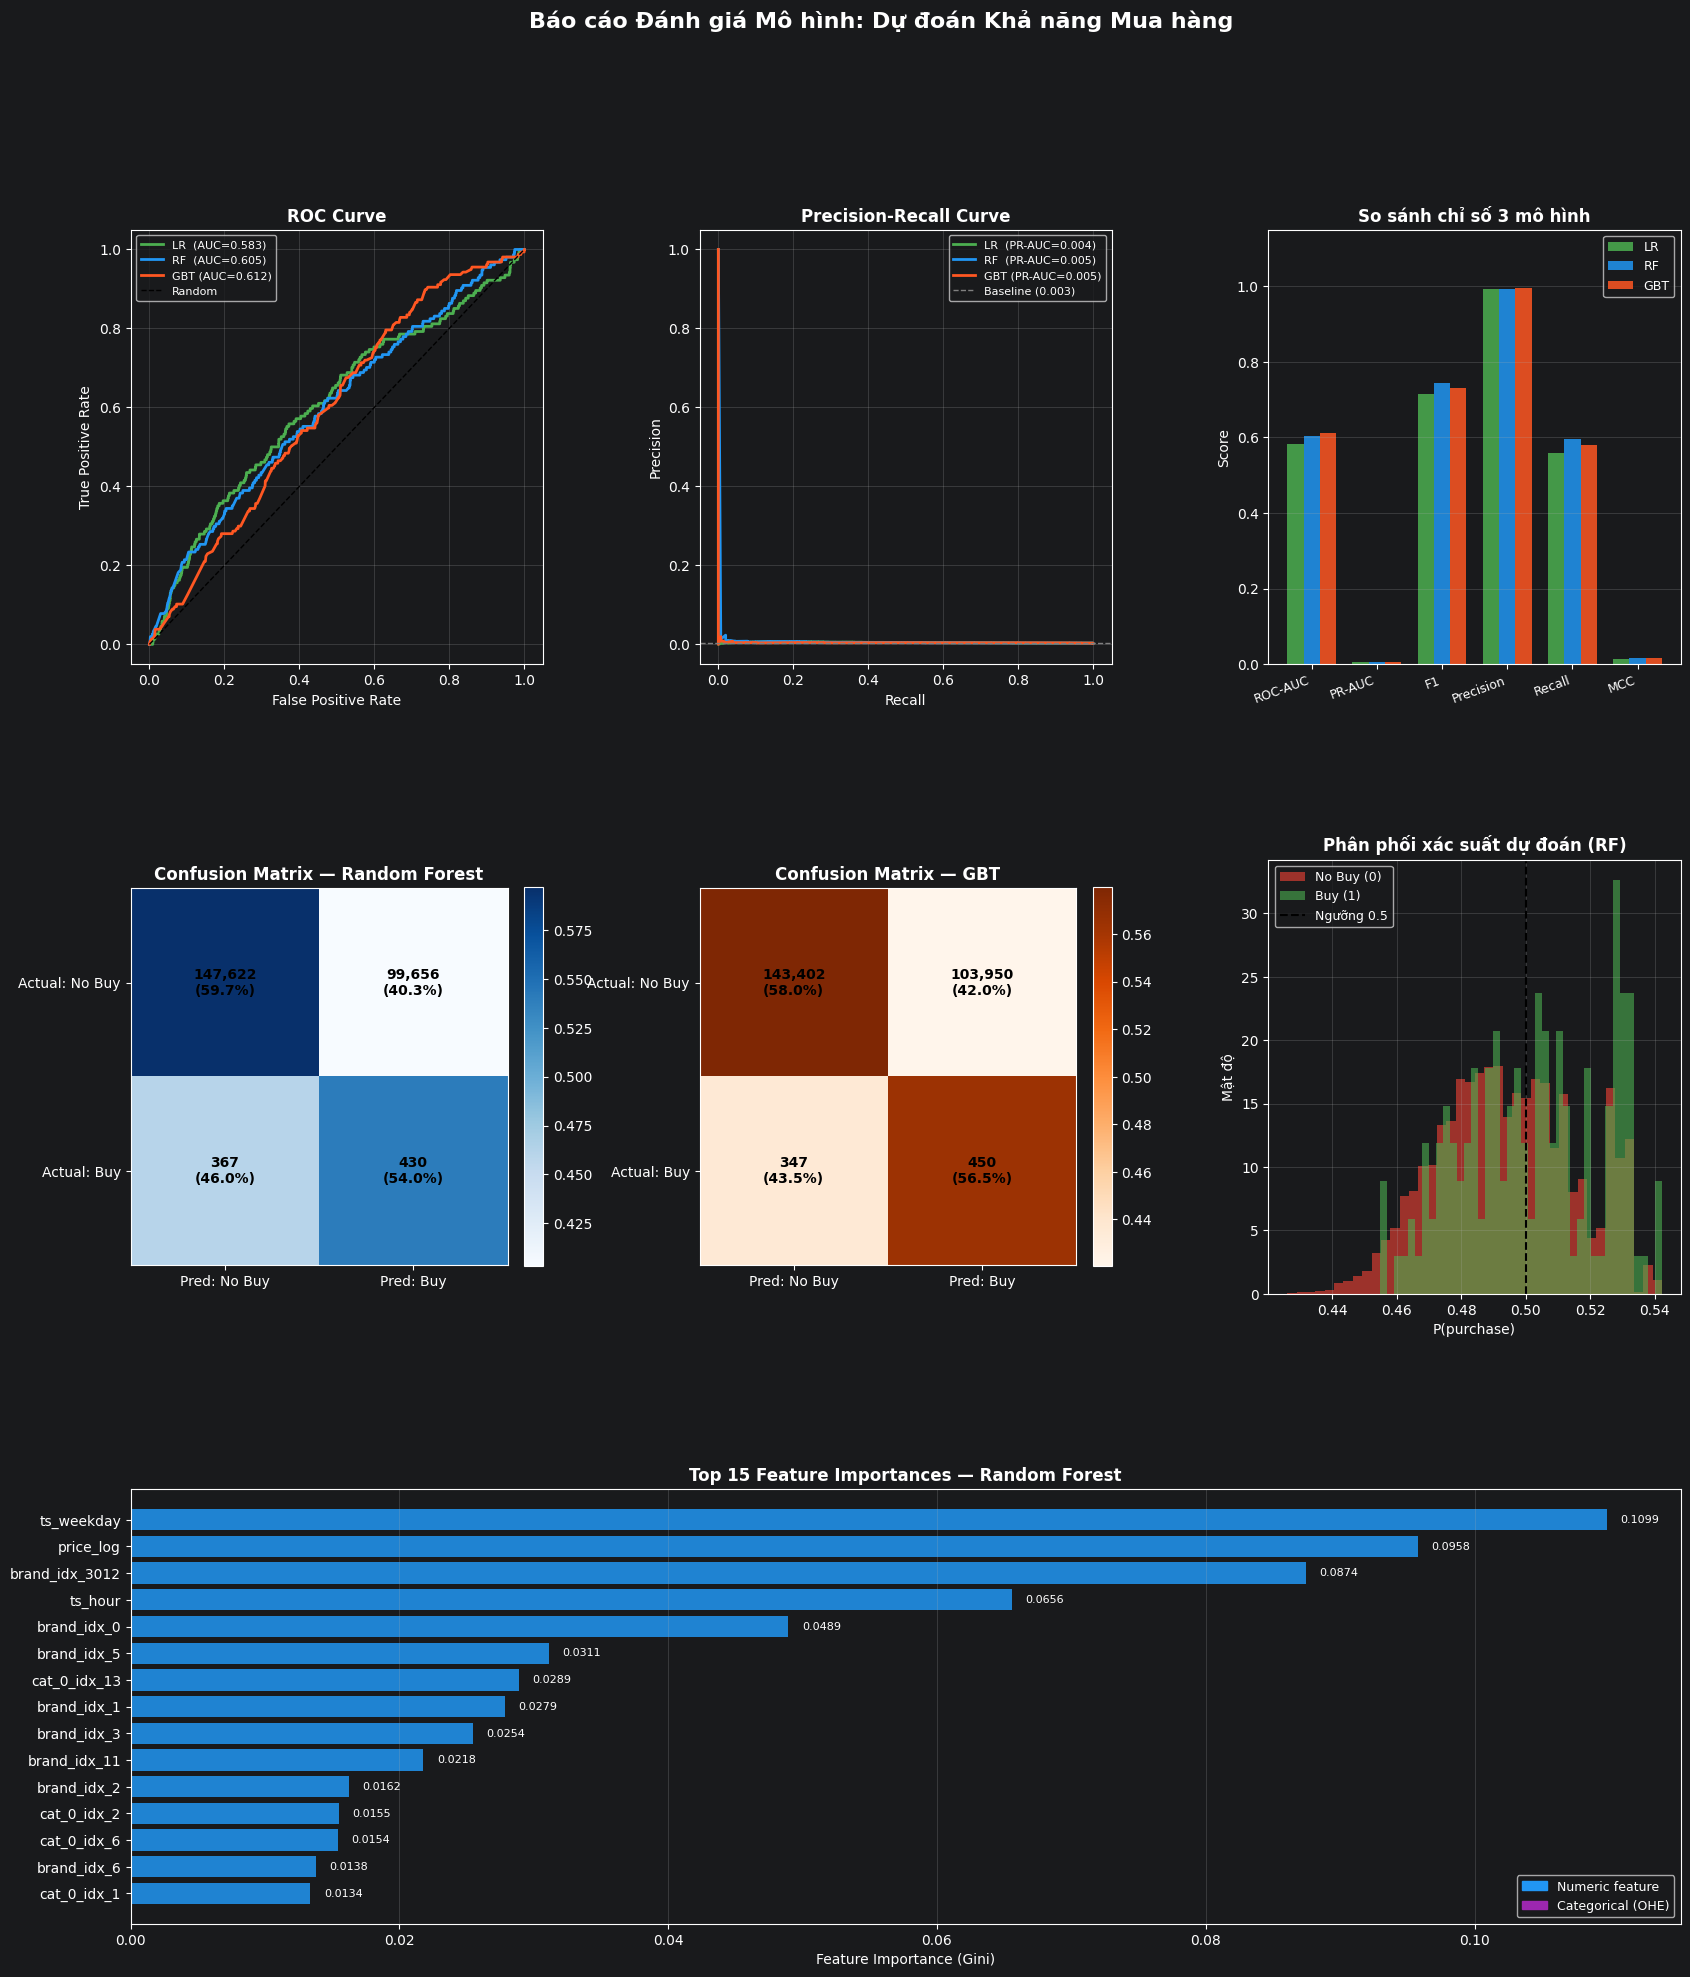

Đã lưu biểu đồ: model_evaluation.png


In [17]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

# Tạo fi_df từ fi_pairs đã tính ở Bước 13
fi_df = pd.DataFrame(fi_pairs[:15], columns=["Feature", "Importance"])

fig = plt.figure(figsize=(20, 22))
fig.suptitle(
    "Báo cáo Đánh giá Mô hình: Dự đoán Khả năng Mua hàng",
    fontsize=16, fontweight="bold", y=0.98
)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

COLORS = {"LR": "#4CAF50", "RF": "#2196F3", "GBT": "#FF5722", "pos": "#4CAF50", "neg": "#F44336"}

# 1. ROC CURVE
ax1 = fig.add_subplot(gs[0, 0])
for pdf, label, color in [
    (pdf_lr,  f"LR  (AUC={metrics_lr['roc_auc']:.3f})",  COLORS["LR"]),
    (pdf_rf,  f"RF  (AUC={metrics_rf['roc_auc']:.3f})",  COLORS["RF"]),
    (pdf_gbt, f"GBT (AUC={metrics_gbt['roc_auc']:.3f})", COLORS["GBT"])
]:
    fpr, tpr, _ = roc_curve(pdf["label"], pdf["prob_1"])
    ax1.plot(fpr, tpr, color=color, lw=2, label=label)
ax1.plot([0,1],[0,1], "k--", lw=1, label="Random")
ax1.set_xlabel("False Positive Rate"); ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve", fontweight="bold")
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

# 2. PRECISION-RECALL CURVE
ax2 = fig.add_subplot(gs[0, 1])
for pdf, label, color in [
    (pdf_lr,  f"LR  (PR-AUC={metrics_lr['pr_auc']:.3f})",  COLORS["LR"]),
    (pdf_rf,  f"RF  (PR-AUC={metrics_rf['pr_auc']:.3f})",  COLORS["RF"]),
    (pdf_gbt, f"GBT (PR-AUC={metrics_gbt['pr_auc']:.3f})", COLORS["GBT"])
]:
    prec, rec, _ = precision_recall_curve(pdf["label"], pdf["prob_1"])
    ax2.plot(rec, prec, color=color, lw=2, label=label)
baseline = pdf_rf["label"].mean()
ax2.axhline(baseline, color="gray", ls="--", lw=1, label=f"Baseline ({baseline:.3f})")
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve", fontweight="bold")
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# 3. BIỂU ĐỒ SO SÁNH CHỈ SỐ ĐÁNH GIÁ (3 mô hình)
ax3 = fig.add_subplot(gs[0, 2])
metrics_keys = ["ROC-AUC", "PR-AUC", "F1", "Precision", "Recall", "MCC"]
vals_lr  = [metrics_lr["roc_auc"],  metrics_lr["pr_auc"],  metrics_lr["f1"],
            metrics_lr["precision"],  metrics_lr["recall"],  max(metrics_lr["mcc"],0)]
vals_rf  = [metrics_rf["roc_auc"],  metrics_rf["pr_auc"],  metrics_rf["f1"],
            metrics_rf["precision"],  metrics_rf["recall"],  max(metrics_rf["mcc"],0)]
vals_gbt = [metrics_gbt["roc_auc"], metrics_gbt["pr_auc"], metrics_gbt["f1"],
            metrics_gbt["precision"], metrics_gbt["recall"], max(metrics_gbt["mcc"],0)]

x = np.arange(len(metrics_keys))
w = 0.25
ax3.bar(x - w, vals_lr,  w, label="LR",  color=COLORS["LR"],  alpha=0.85)
ax3.bar(x,     vals_rf,  w, label="RF",  color=COLORS["RF"],  alpha=0.85)
ax3.bar(x + w, vals_gbt, w, label="GBT", color=COLORS["GBT"], alpha=0.85)
ax3.set_xticks(x); ax3.set_xticklabels(metrics_keys, rotation=20, ha="right", fontsize=9)
ax3.set_ylim(0, 1.15); ax3.set_ylabel("Score")
ax3.set_title("So sánh chỉ số 3 mô hình", fontweight="bold")
ax3.legend(fontsize=9); ax3.grid(axis="y", alpha=0.3)

# 4. CONFUSION MATRIX — RANDOM FOREST
ax4 = fig.add_subplot(gs[1, 0])
cm_rf   = np.array([[metrics_rf["TN"],  metrics_rf["FP"]],
                    [metrics_rf["FN"],  metrics_rf["TP"]]])
cm_norm = cm_rf / cm_rf.sum(axis=1, keepdims=True)
im = ax4.imshow(cm_norm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax4.text(j, i, f"{cm_rf[i,j]:,}\n({cm_norm[i,j]:.1%})",
         ha="center", va="center", fontsize=10, fontweight="bold",
         color="white" if cm_norm[i,j] > 0.6 else "black")
ax4.set_xticks([0,1]); ax4.set_yticks([0,1])
ax4.set_xticklabels(["Pred: No Buy","Pred: Buy"])
ax4.set_yticklabels(["Actual: No Buy","Actual: Buy"])
ax4.set_title("Confusion Matrix — Random Forest", fontweight="bold")
plt.colorbar(im, ax=ax4, fraction=0.046, pad=0.04)

# 5. CONFUSION MATRIX — GBT
ax5 = fig.add_subplot(gs[1, 1])
cm_gbt  = np.array([[metrics_gbt["TN"], metrics_gbt["FP"]],
                    [metrics_gbt["FN"], metrics_gbt["TP"]]])
cm_norm2 = cm_gbt / cm_gbt.sum(axis=1, keepdims=True)
im2 = ax5.imshow(cm_norm2, cmap="Oranges")
for i in range(2):
    for j in range(2):
        ax5.text(j, i, f"{cm_gbt[i,j]:,}\n({cm_norm2[i,j]:.1%})",
         ha="center", va="center", fontsize=10, fontweight="bold",
         color="white" if cm_norm2[i,j] > 0.6 else "black")
ax5.set_xticks([0,1]); ax5.set_yticks([0,1])
ax5.set_xticklabels(["Pred: No Buy","Pred: Buy"])
ax5.set_yticklabels(["Actual: No Buy","Actual: Buy"])
ax5.set_title("Confusion Matrix — GBT", fontweight="bold")
plt.colorbar(im2, ax=ax5, fraction=0.046, pad=0.04)

# 6. PHÂN PHỐI XÁC SUẤT DỰ ĐOÁN (RF)
ax6 = fig.add_subplot(gs[1, 2])
for lbl, color, name in [(0, COLORS["neg"], "No Buy (0)"), (1, COLORS["pos"], "Buy (1)")]:
    subset = pdf_rf[pdf_rf["label"] == lbl]["prob_1"]
    ax6.hist(subset, bins=40, alpha=0.6, color=color, label=name, density=True)
ax6.axvline(0.5, color="black", ls="--", lw=1.5, label="Ngưỡng 0.5")
ax6.set_xlabel("P(purchase)"); ax6.set_ylabel("Mật độ")
ax6.set_title("Phân phối xác suất dự đoán (RF)", fontweight="bold")
ax6.legend(fontsize=9); ax6.grid(alpha=0.3)

# 7. FEATURE IMPORTANCE
ax7 = fig.add_subplot(gs[2, :])
colors_fi = [COLORS["RF"] if "_ohe" not in f else "#9C27B0" for f in fi_df["Feature"]]
bars = ax7.barh(fi_df["Feature"][::-1], fi_df["Importance"][::-1],
                color=colors_fi[::-1], alpha=0.85)
for bar, val in zip(bars, fi_df["Importance"][::-1]):
    ax7.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f"{val:.4f}", va="center", fontsize=8)
patch_num = mpatches.Patch(color=COLORS["RF"],  label="Numeric feature")
patch_cat = mpatches.Patch(color="#9C27B0",     label="Categorical (OHE)")
ax7.legend(handles=[patch_num, patch_cat], fontsize=9)
ax7.set_xlabel("Feature Importance (Gini)")
ax7.set_title("Top 15 Feature Importances — Random Forest", fontweight="bold")
ax7.grid(axis="x", alpha=0.3)

plt.savefig("model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Đã lưu biểu đồ: model_evaluation.png")

### Bước 16: Phân tích xu hướng xác suất mua theo giờ & ngày

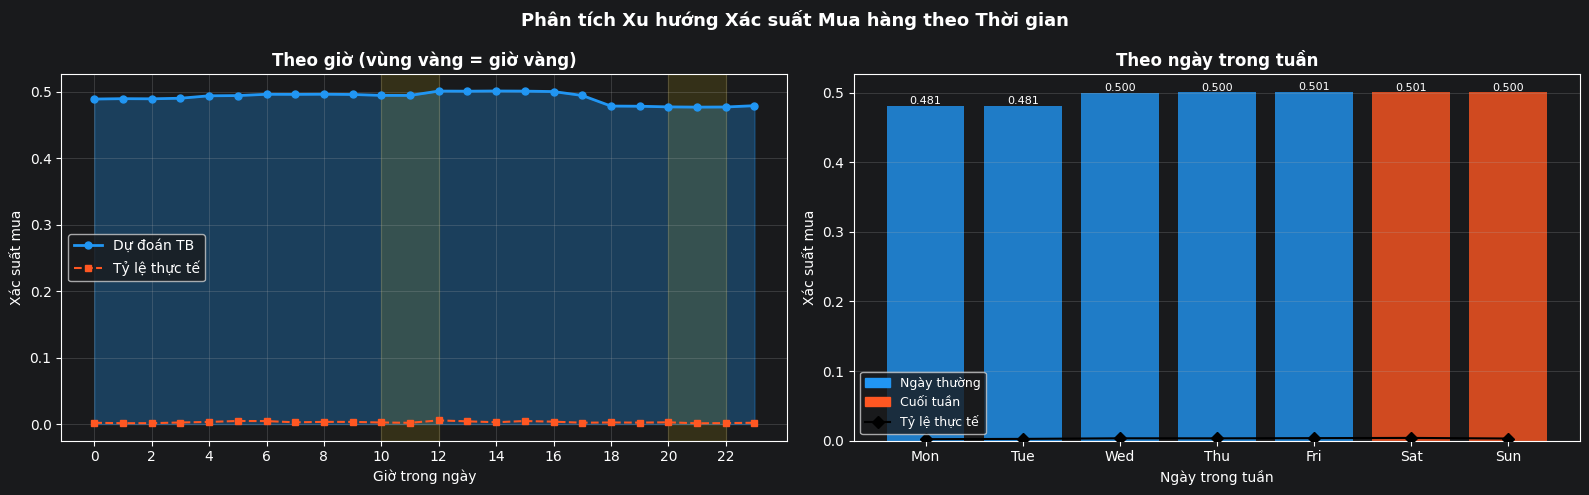

Đã lưu biểu đồ: time_analysis.png


In [32]:
from pyspark.ml.functions import vector_to_array

hourly_df = pred_rf \
    .withColumn("prob_purchase", vector_to_array(F.col("probability"))[1]) \
    .groupBy("ts_hour") \
    .agg(
        F.mean("prob_purchase").alias("avg_prob"),
        F.mean("label").alias("actual_rate"),
        F.count("*").alias("n")
    ) \
    .orderBy("ts_hour") \
    .toPandas()

weekday_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
daily_df = pred_rf \
    .withColumn("prob_purchase", vector_to_array(F.col("probability"))[1]) \
    .groupBy("ts_weekday") \
    .agg(
        F.mean("prob_purchase").alias("avg_prob"),
        F.mean("label").alias("actual_rate")
    ) \
    .orderBy("ts_weekday") \
    .toPandas()
daily_df["day_label"] = daily_df["ts_weekday"].apply(
    lambda x: weekday_labels[int(x)] if int(x) < 7 else str(x)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Phân tích Xu hướng Xác suất Mua hàng theo Thời gian",
             fontsize=13, fontweight="bold")

# --- Biểu đồ theo giờ ---
ax = axes[0]
ax.fill_between(hourly_df["ts_hour"], hourly_df["avg_prob"], alpha=0.3, color=COLORS["RF"])
ax.plot(hourly_df["ts_hour"], hourly_df["avg_prob"],
        color=COLORS["RF"], lw=2, marker="o", ms=5, label="Dự đoán TB")
ax.plot(hourly_df["ts_hour"], hourly_df["actual_rate"],
        color=COLORS["GBT"], lw=1.5, ls="--", marker="s", ms=4, label="Tỷ lệ thực tế")
for span in [(10, 12), (20, 22)]:
    ax.axvspan(span[0], span[1], alpha=0.12, color="gold")
ax.set_xlabel("Giờ trong ngày"); ax.set_ylabel("Xác suất mua")
ax.set_title("Theo giờ (vùng vàng = giờ vàng)", fontweight="bold")
ax.set_xticks(range(0, 24, 2)); ax.legend(); ax.grid(alpha=0.3)

# --- Biểu đồ theo ngày ---
ax = axes[1]
bar_colors = [COLORS["GBT"] if d in ["Sat","Sun"] else COLORS["RF"]
              for d in daily_df["day_label"]]
ax.bar(daily_df["day_label"], daily_df["avg_prob"], color=bar_colors, alpha=0.8)

line_actual, = ax.plot(daily_df["day_label"], daily_df["actual_rate"],
        color="black", lw=1.5, marker="D", ms=6, zorder=5)

for i, (d, v) in enumerate(zip(daily_df["day_label"], daily_df["avg_prob"])):
    ax.text(i, v + 0.002, f"{v:.3f}", ha="center", fontsize=8)

wd_patch = mpatches.Patch(color=COLORS["RF"],  label="Ngày thường")
we_patch = mpatches.Patch(color=COLORS["GBT"], label="Cuối tuần")
ax.legend(handles=[wd_patch, we_patch, line_actual],
          labels=["Ngày thường", "Cuối tuần", "Tỷ lệ thực tế"], fontsize=9)
ax.set_xlabel("Ngày trong tuần"); ax.set_ylabel("Xác suất mua")
ax.set_title("Theo ngày trong tuần", fontweight="bold")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("time_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Đã lưu biểu đồ: time_analysis.png")

### Bước 17: Lưu mô hình tốt nhất lên HDFS

In [37]:
best_model_name = best["model"]
if best_model_name == "Logistic Regression":
    best_pipeline = model_lr
elif best_model_name == "Random Forest":
    best_pipeline = model_rf
else:
    best_pipeline = model_gbt

save_path = f"hdfs://master:9000/data/models/purchase_prediction_{best_model_name.replace(' ','_').lower()}"

best_pipeline.write().overwrite().save(save_path)
print(f"✅ Đã lưu mô hình '{best_model_name}' lên HDFS:")
print(f"   {save_path}")

✅ Đã lưu mô hình 'Random Forest' lên HDFS:
   hdfs://master:9000/data/models/purchase_prediction_random_forest


### Bước 18: Ứng dụng thực tiễn - Phân khúc khách hàng có xác suất mua cao

In [40]:
THRESHOLD_HIGH   = 0.7
THRESHOLD_MEDIUM = 0.4

from pyspark.ml.functions import vector_to_array

pred_application = pred_rf \
    .withColumn(
        "prob_purchase",
        vector_to_array("probability")[1]
    ) \
    .filter(F.col("label") == 0)

segments = pred_application \
    .withColumn(
        "segment",
        F.when(F.col("prob_purchase") >= THRESHOLD_HIGH,   "Ưu tiên cao — Gửi mã FREESHIP ngay")
         .when(F.col("prob_purchase") >= THRESHOLD_MEDIUM, "Ưu tiên TB  — Nhắc nhở giỏ hàng")
         .otherwise("Ưu tiên thấp — Chiến dịch retarget")
    )

print("\n PHÂN KHÚC KHÁCH HÀNG BỎ GIỎ THEO DỰ ĐOÁN CỦA MÔ HÌNH:")
segments.groupBy("segment") \
    .agg(
        F.count("*").alias("so_khach"),
        F.round(F.mean("prob_purchase"), 4).alias("xac_suat_tb"),
        F.round(F.mean("price"), 2).alias("gia_tb")
    ) \
    .orderBy(F.desc("xac_suat_tb")) \
    .show(truncate=False)

high_value = segments.filter(F.col("prob_purchase") >= THRESHOLD_HIGH).count()
print(f"\n Insight: Có {high_value:,} khách hàng cần can thiệp ngay (Xác suất chốt đơn ≥ {THRESHOLD_HIGH}).")
print("   → Gửi push notification 'FREESHIP trong 2 giờ' để tạo FOMO và thúc đẩy chốt đơn!")


 PHÂN KHÚC KHÁCH HÀNG BỎ GIỎ THEO DỰ ĐOÁN CỦA MÔ HÌNH:
+-------------------------------+--------+-----------+------+
|segment                        |so_khach|xac_suat_tb|gia_tb|
+-------------------------------+--------+-----------+------+
|Ưu tiên TB  — Nhắc nhở giỏ hàng|247278  |0.4944     |225.23|
+-------------------------------+--------+-----------+------+


 Insight: Có 0 khách hàng cần can thiệp ngay (Xác suất chốt đơn ≥ 0.7).
   → Gửi push notification 'FREESHIP trong 2 giờ' để tạo FOMO và thúc đẩy chốt đơn!


### Bước 19: Tổng kết & đóng SparkSession

In [43]:
print("\n" + "="*65)
print("  TỔNG KẾT BÀI TOÁN DỰ ĐOÁN KHẢ NĂNG MUA HÀNG")
print("="*65)
print(f"  Thuật toán tốt nhất : {best['model']}")
print(f"  ROC-AUC             : {best['roc_auc']:.4f}")
print(f"  F1-Score            : {best['f1_pos']:.4f}  (↑ ưu tiên vì dữ liệu mất cân bằng)")   # ← SỬA
print(f"  MCC                 : {best['mcc']:.4f}  (↑ đáng tin cậy nhất)")
print(f"  Precision           : {best['precision_pos']:.4f}")   # ← SỬA
print(f"  Recall              : {best['recall_pos']:.4f}")      # ← SỬA
print("\n  Ba mô hình đã so sánh:")
print(f"  [LR]  F1={metrics_lr['f1_pos']:.4f}  AUC={metrics_lr['roc_auc']:.4f}  MCC={metrics_lr['mcc']:.4f}")    # ← SỬA
print(f"  [RF]  F1={metrics_rf['f1_pos']:.4f}  AUC={metrics_rf['roc_auc']:.4f}  MCC={metrics_rf['mcc']:.4f}")    # ← SỬA
print(f"  [GBT] F1={metrics_gbt['f1_pos']:.4f}  AUC={metrics_gbt['roc_auc']:.4f}  MCC={metrics_gbt['mcc']:.4f}")# ← SỬA
print("\n  Pipeline tiền xử lý:")
print("  StringIndexer → OneHotEncoder → VectorAssembler → StandardScaler")
print("\n  Features sử dụng:")
print(f"  Numeric  : {numeric_cols}")
print(f"  Categorical (OHE): {cat_cols}")
print("\n  Ứng dụng:")
print("  Gửi mã FREESHIP tự động cho khách hàng P≥0.7 chưa chốt đơn")
print("="*65)

spark.stop()
print("\n SparkSession đã đóng.")


  TỔNG KẾT BÀI TOÁN DỰ ĐOÁN KHẢ NĂNG MUA HÀNG
  Thuật toán tốt nhất : Random Forest
  ROC-AUC             : 0.6049
  F1-Score            : 0.7446  (↑ ưu tiên vì dữ liệu mất cân bằng)
  MCC                 : 0.0157  (↑ đáng tin cậy nhất)
  Precision           : 0.9943
  Recall              : 0.5968

  Ba mô hình đã so sánh:
  [LR]  F1=0.7138  AUC=0.5835  MCC=0.0137
  [RF]  F1=0.7446  AUC=0.6049  MCC=0.0157
  [GBT] F1=0.7310  AUC=0.6124  MCC=0.0165

  Pipeline tiền xử lý:
  StringIndexer → OneHotEncoder → VectorAssembler → StandardScaler

  Features sử dụng:
  Numeric  : ['price_log', 'is_golden_hour', 'ts_hour', 'ts_weekday']
  Categorical (OHE): ['brand', 'cat_0', 'session_part']

  Ứng dụng:
  Gửi mã FREESHIP tự động cho khách hàng P≥0.7 chưa chốt đơn

 SparkSession đã đóng.
